# Problem 1.2 - VAE Loss Function (KLD + Reconstruction)
### Dataset: MNIST (CSV format)
### Goal: Train a VAE and separately plot Total Loss, KLD, and Reconstruction Loss over 20 epochs

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

## 1. Load MNIST from CSV

In [3]:
train_df = pd.read_csv('../../../MNIST/mnist_train.csv')
test_df  = pd.read_csv('../../../MNIST/mnist_test.csv')

# Separate pixels from labels
X_train = train_df.iloc[:, 1:].values.astype('float32') / 255.0
X_test  = test_df.iloc[:, 1:].values.astype('float32')  / 255.0

print(f"Train shape: {X_train.shape}")  # (60000, 784)
print(f"Test shape:  {X_test.shape}")

Train shape: (60000, 784)
Test shape:  (10000, 784)


## 2. Dataset and DataLoader

In [4]:
class MNISTDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


train_loader = DataLoader(MNISTDataset(X_train), batch_size=128, shuffle=True)
test_loader  = DataLoader(MNISTDataset(X_test),  batch_size=128, shuffle=False)

## 3. VAE Model

In [5]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()

        # Encoder
        self.fc1    = nn.Linear(input_dim, hidden_dim)
        self.fc_mu  = nn.Linear(hidden_dim, latent_dim)   # mean
        self.fc_var = nn.Linear(hidden_dim, latent_dim)   # log variance

        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h   = torch.relu(self.fc1(x))
        mu  = self.fc_mu(h)
        log_var = self.fc_var(h)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)       # sample noise
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))  # output in [0, 1]

    def forward(self, x):
        mu, log_var = self.encode(x)
        z           = self.reparameterize(mu, log_var)
        x_recon     = self.decode(z)
        return x_recon, mu, log_var

## 4. VAE Loss Function
**Total Loss = Reconstruction Loss (BCE) + β × KLD**

- **BCE** measures how well the decoder reconstructs the input.
- **KLD** pushes the latent distribution towards a standard Normal N(0, I).
- **β (kld_weight)** controls the balance between the two terms.

In [6]:
def vae_loss(x_recon, x, mu, log_var, kld_weight=1.0):
    # Reconstruction loss (sum over pixels, mean over batch)
    recon_loss = nn.functional.binary_cross_entropy(x_recon, x, reduction='sum') / x.size(0)

    # KL Divergence: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    kld = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)

    total = recon_loss + kld_weight * kld
    return total, recon_loss, kld

## 5. Training Loop

In [7]:
def train_vae(kld_weight=1.0, epochs=20):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model  = VAE().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    history = {'total': [], 'recon': [], 'kld': []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = recon_total = kld_total = 0

        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()

            x_recon, mu, log_var = model(batch)
            loss, recon, kld = vae_loss(x_recon, batch, mu, log_var, kld_weight)

            loss.backward()
            optimizer.step()

            total_loss  += loss.item()
            recon_total += recon.item()
            kld_total   += kld.item()

        n = len(train_loader)
        history['total'].append(total_loss / n)
        history['recon'].append(recon_total / n)
        history['kld'].append(kld_total / n)

        print(f"Epoch {epoch:2d} | Total: {history['total'][-1]:.2f} | "
              f"Recon: {history['recon'][-1]:.2f} | KLD: {history['kld'][-1]:.2f}")

    return model, history

In [8]:
# Train with default KLD weight = 1.0
model, history = train_vae(kld_weight=1.0, epochs=20)

Epoch  1 | Total: 164.45 | Recon: 148.98 | KLD: 15.47
Epoch  2 | Total: 120.96 | Recon: 98.53 | KLD: 22.43
Epoch  3 | Total: 114.20 | Recon: 90.25 | KLD: 23.96
Epoch  4 | Total: 111.40 | Recon: 86.94 | KLD: 24.47
Epoch  5 | Total: 109.73 | Recon: 84.99 | KLD: 24.74
Epoch  6 | Total: 108.61 | Recon: 83.70 | KLD: 24.91
Epoch  7 | Total: 107.76 | Recon: 82.75 | KLD: 25.01
Epoch  8 | Total: 107.15 | Recon: 82.04 | KLD: 25.10
Epoch  9 | Total: 106.63 | Recon: 81.47 | KLD: 25.16
Epoch 10 | Total: 106.19 | Recon: 81.00 | KLD: 25.19
Epoch 11 | Total: 105.86 | Recon: 80.60 | KLD: 25.27
Epoch 12 | Total: 105.55 | Recon: 80.26 | KLD: 25.28
Epoch 13 | Total: 105.32 | Recon: 79.98 | KLD: 25.34
Epoch 14 | Total: 105.04 | Recon: 79.69 | KLD: 25.35
Epoch 15 | Total: 104.90 | Recon: 79.49 | KLD: 25.40
Epoch 16 | Total: 104.62 | Recon: 79.26 | KLD: 25.37
Epoch 17 | Total: 104.47 | Recon: 79.07 | KLD: 25.40
Epoch 18 | Total: 104.29 | Recon: 78.87 | KLD: 25.42
Epoch 19 | Total: 104.15 | Recon: 78.74 | KLD

## 6. Plot Losses Over 20 Epochs

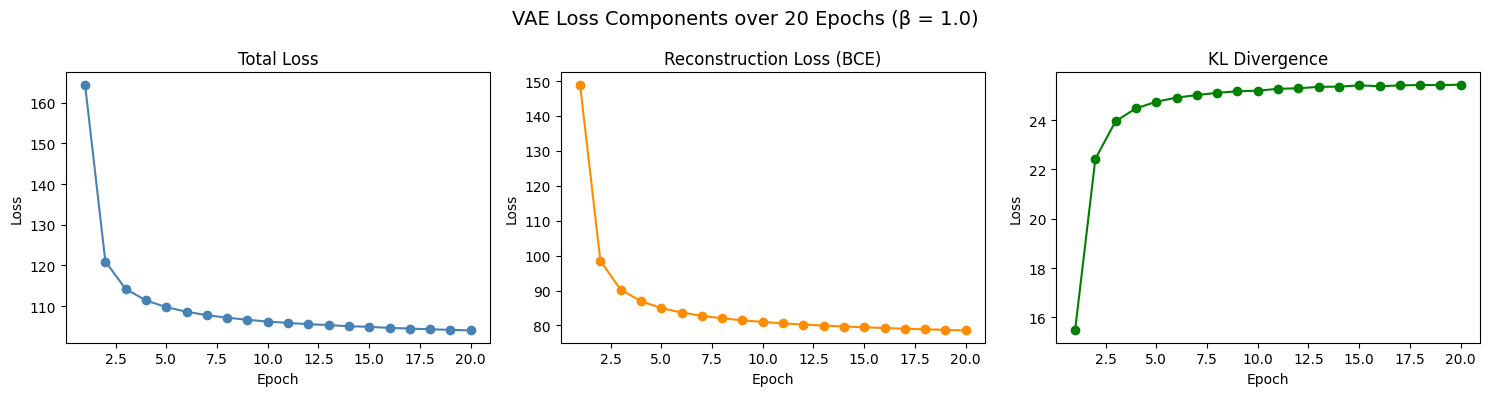

In [9]:
epochs = range(1, 21)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('VAE Loss Components over 20 Epochs (β = 1.0)', fontsize=14)

axes[0].plot(epochs, history['total'], color='steelblue', marker='o')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(epochs, history['recon'], color='darkorange', marker='o')
axes[1].set_title('Reconstruction Loss (BCE)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

axes[2].plot(epochs, history['kld'], color='green', marker='o')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')

plt.tight_layout()
plt.savefig('loss_plot_beta1.png', dpi=150)
plt.show()

## 7. Effect of KLD Weight on Reconstruction Sharpness
Train with a high β (e.g. β = 5) and compare reconstructed images.

In [10]:
# Train two models: low β and high β
print("Training with β = 0.1 (low KLD weight)...")
model_low_beta, history_low = train_vae(kld_weight=0.1, epochs=20)

print("\nTraining with β = 5.0 (high KLD weight)...")
model_high_beta, history_high = train_vae(kld_weight=5.0, epochs=20)

Training with β = 0.1 (low KLD weight)...
Epoch  1 | Total: 140.64 | Recon: 135.46 | KLD: 51.74
Epoch  2 | Total: 90.69 | Recon: 84.48 | KLD: 62.02
Epoch  3 | Total: 83.52 | Recon: 77.56 | KLD: 59.62
Epoch  4 | Total: 80.47 | Recon: 74.70 | KLD: 57.76
Epoch  5 | Total: 78.61 | Recon: 72.95 | KLD: 56.61
Epoch  6 | Total: 77.32 | Recon: 71.73 | KLD: 55.92
Epoch  7 | Total: 76.38 | Recon: 70.85 | KLD: 55.37
Epoch  8 | Total: 75.65 | Recon: 70.14 | KLD: 55.01
Epoch  9 | Total: 75.05 | Recon: 69.57 | KLD: 54.76
Epoch 10 | Total: 74.59 | Recon: 69.13 | KLD: 54.62
Epoch 11 | Total: 74.18 | Recon: 68.73 | KLD: 54.49
Epoch 12 | Total: 73.83 | Recon: 68.39 | KLD: 54.39
Epoch 13 | Total: 73.51 | Recon: 68.08 | KLD: 54.31
Epoch 14 | Total: 73.24 | Recon: 67.81 | KLD: 54.25
Epoch 15 | Total: 72.97 | Recon: 67.55 | KLD: 54.23
Epoch 16 | Total: 72.75 | Recon: 67.33 | KLD: 54.23
Epoch 17 | Total: 72.56 | Recon: 67.14 | KLD: 54.18
Epoch 18 | Total: 72.39 | Recon: 66.96 | KLD: 54.22
Epoch 19 | Total: 72

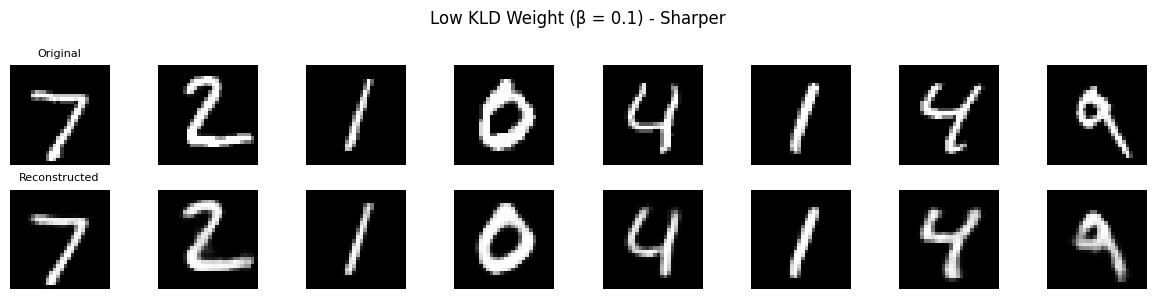

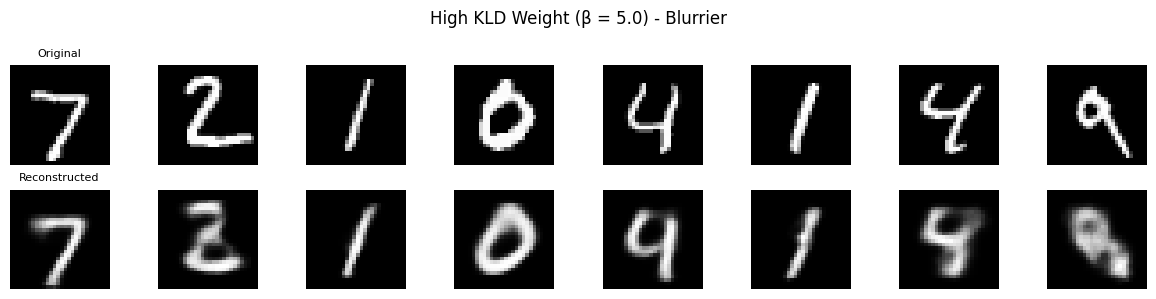

In [11]:
def show_reconstructions(model, title, n=8):
    device = next(model.parameters()).device
    model.eval()

    # Take first n samples from test set
    samples = torch.tensor(X_test[:n]).to(device)

    with torch.no_grad():
        recon, _, _ = model(samples)

    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    fig.suptitle(title, fontsize=12)

    for i in range(n):
        axes[0, i].imshow(samples[i].cpu().reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=8)

        axes[1, i].imshow(recon[i].cpu().reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstructed', fontsize=8)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150)
    plt.show()


show_reconstructions(model_low_beta,  'Low KLD Weight (β = 0.1) - Sharper')
show_reconstructions(model_high_beta, 'High KLD Weight (β = 5.0) - Blurrier')

## 8. Combined Loss Comparison Plot (Low β vs High β)

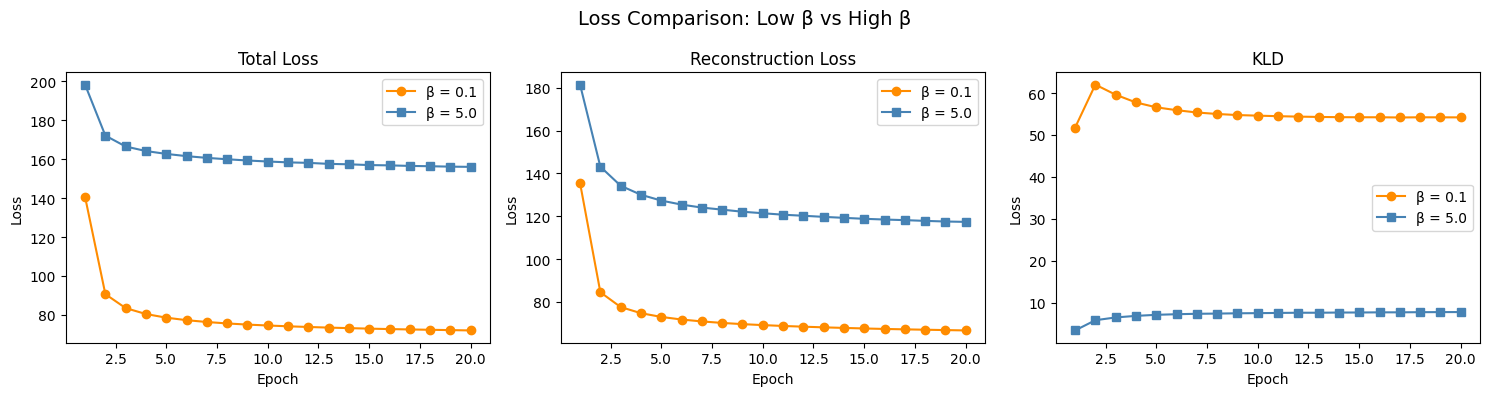

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Loss Comparison: Low β vs High β', fontsize=14)

labels = ['Total Loss', 'Reconstruction Loss', 'KLD']
keys   = ['total', 'recon', 'kld']

for ax, label, key in zip(axes, labels, keys):
    ax.plot(epochs, history_low[key],  label='β = 0.1', color='darkorange', marker='o')
    ax.plot(epochs, history_high[key], label='β = 5.0', color='steelblue',  marker='s')
    ax.set_title(label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=150)
plt.show()

## 9. Observation

### What happens to sharpness when KLD weight (β) is increased?

| β (KLD Weight) | Reconstruction Loss | KLD Loss | Image Quality |
|---------------|-------------------|----------|---------------|
| Low (0.1)     | Lower             | Higher   | Sharper, crisper digits |
| High (5.0)    | Higher            | Lower    | Blurrier, smoother but less detailed |

**Explanation:**
- When β is **low**, the model focuses mostly on reconstruction → the decoder learns to produce sharp, detailed images that closely match the input.
- When β is **high**, the model is forced to compress information into a tightly regularized latent space (closer to N(0,1)) → the decoder loses fine-grained detail, resulting in **blurrier reconstructions**.
- This is the classic **sharpness vs. regularity tradeoff** in VAEs. A well-regularized latent space (high KLD weight) improves generation quality from random samples but degrades reconstruction sharpness.